## Training result comparison
Experiments to compare:
- Before: Regularize experiment 04 (Decrease batch size)
- After: Regularize experiment 09 (Increase weight decay rate)

## Setup
Set up file system for the datset(using Google Drive), dagshub and MLflow

In [2]:
# Install dependencies
%%capture
%pip install -q dagshub[jupyter]

In [2]:
# Mount google drive
from google.colab import drive
drive.mount('/content/drive')

# Set up dagshub
!dagshub login
import dagshub
TOKEN = dagshub.auth.get_token()

Mounted at /content/drive
                                ❗❗❗ AUTHORIZATION REQUIRED ❗❗❗                                


Open the following link in your browser to authorize the client:
https://dagshub.com/login/oauth/authorize?state=aa65e09d-1d80-4639-b107-20bb2a681a77&client_id=32b60ba385aa7cecf24046d8195a71c07dd345d9657977863b52e7748e0f0f28&middleman_request_id=f94a2d6fd3b21e6a5c8e9f786d5a50568aa49b894d99f3c93ba24e7e69265212


⠙ Waiting for authorization
✅ OAuth token added


Accessing as chengzwk

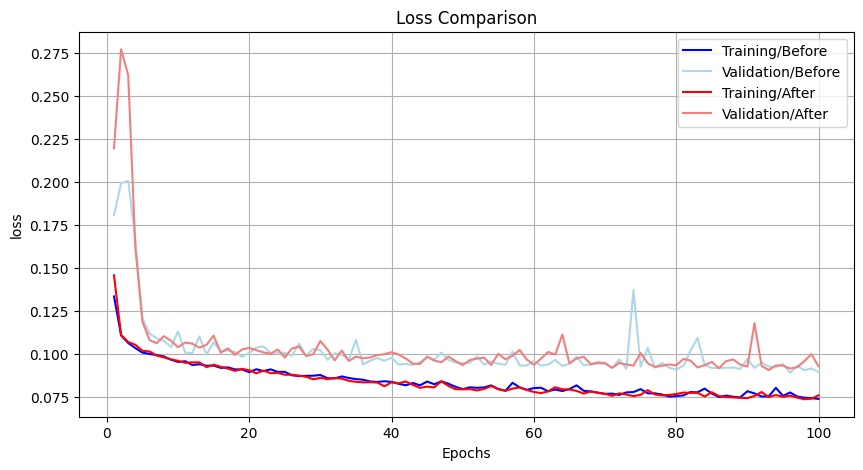

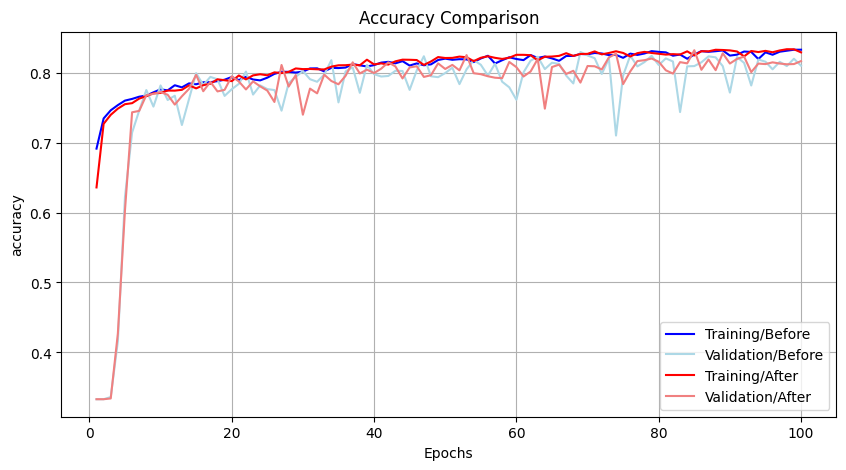

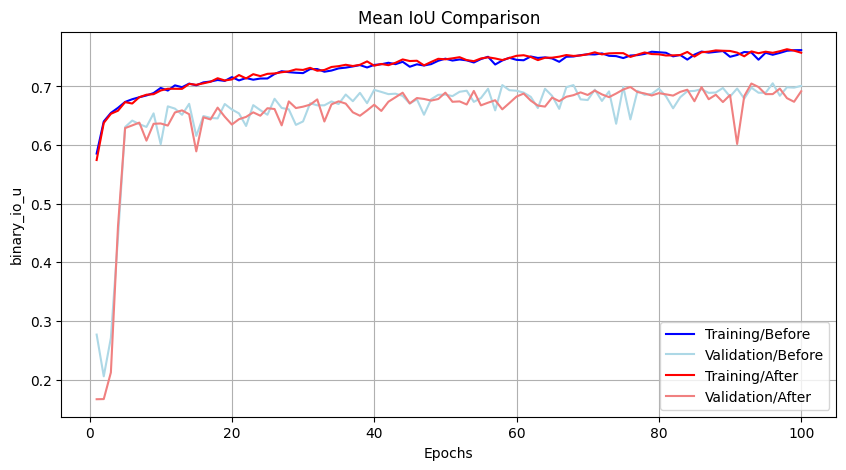


Comparison of Key Metrics:
Metric          Before     After      Change    
Loss            0.0937     0.0985     0.0048    
Accuracy        0.7860     0.7850     -0.0010   
Precision       0.8719     0.8753     0.0034    
Recall          0.8638     0.8447     -0.0191   
F1 Score        0.8678     0.8597     -0.0081   
Mean IoU        0.7102     0.7000     -0.0102   
IoU for class 1 0.7665     0.7539     -0.0126   
AUC             0.8302     0.8259     -0.0043   


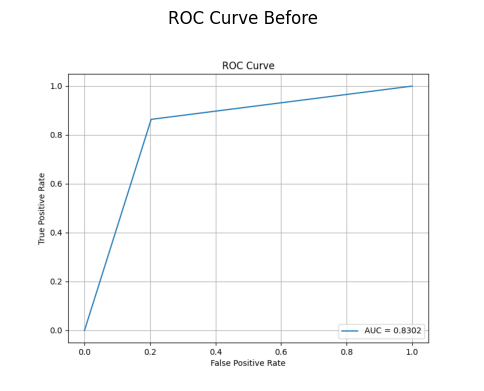

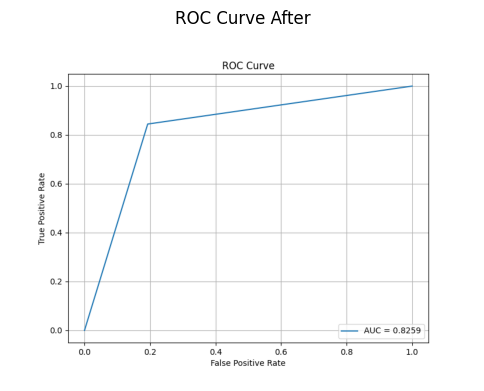

In [3]:
import os
import numpy as np
import pickle
import matplotlib.pyplot as plt


def plot_comparison(history_before, history_after, train_metric, val_metric, title, \
                    train_metric_before=None, val_metric_before=None):
    if train_metric_before is not None:
        epochs_before = range(1, len(history_before[train_metric_before]) + 1)
    else:
        epochs_before = range(1, len(history_before[train_metric]) + 1)
    epochs_after = range(1, len(history_after[train_metric]) + 1)

    plt.figure(figsize=(10, 5))
    if train_metric_before is not None:
        plt.plot(epochs_before, history_before[train_metric_before], 'blue', label=f'Training/Before')
        plt.plot(epochs_before, history_before[val_metric_before], 'lightblue', label=f'Validation/Before')
    else:
        plt.plot(epochs_before, history_before[train_metric], 'blue', label=f'Training/Before')
        plt.plot(epochs_before, history_before[val_metric], 'lightblue', label=f'Validation/Before')

    plt.plot(epochs_after, history_after[train_metric], 'red', label=f'Training/After')
    plt.plot(epochs_after, history_after[val_metric], 'lightcoral', label=f'Validation/After')
    plt.xlabel('Epochs')
    plt.ylabel(train_metric)
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

# Set paths
experiment_label_before = 'experiment04_decrease_batch_size'
experiment_label_after = 'experiment09_increase_weight_decay'
result_dir_before = os.path.join('/content/drive/My Drive/regularize_experiment_results', experiment_label_before)
result_dir_after = os.path.join('/content/drive/My Drive/regularize_experiment_results', experiment_label_after)

# Load histories
def load_history(filepath):
    with open(filepath, 'rb') as f:
        return pickle.load(f)

history_before = load_history(os.path.join(result_dir_before, "unet_training_history.pkl"))
history_after = load_history(os.path.join(result_dir_after, "unet_training_history.pkl"))

# Compare Loss
plot_comparison(history_before, history_after, "loss", "val_loss","Loss Comparison")

# Compare Accuracy
plot_comparison(history_before, history_after, "accuracy", "val_accuracy", "Accuracy Comparison")

# Compare IoU
plot_comparison(history_before, history_after, "binary_io_u", "val_binary_io_u", "Mean IoU Comparison")

# Assuming you manually recorded the final evaluation metrics:
metrics_before = {
    "Loss": 0.0937,
    "Accuracy": 0.7860,
    "Precision": 0.8719,
    "Recall": 0.8638,
    "F1 Score": 0.8678,
    "Mean IoU": 0.7102,
    "IoU for class 1": 0.7665,
    "AUC": 0.8302
}

metrics_after = {
    "Loss": 0.0985,
    "Accuracy": 0.7850,
    "Precision": 0.8753,
    "Recall": 0.8447,
    "F1 Score": 0.8597,
    "Mean IoU": 0.7000,
    "IoU for class 1": 0.7539,
    "AUC": 0.8259
}


# Compare in a table
print("\nComparison of Key Metrics:")
print(f"{'Metric':<15} {'Before':<10} {'After':<10} {'Change':<10}")
for key in metrics_before:
    change = metrics_after[key] - metrics_before[key]
    print(f"{key:<15} {metrics_before[key]:<10.4f} {metrics_after[key]:<10.4f} {change:<10.4f}")


from PIL import Image

roc_path_before = os.path.join(result_dir_before, "ROC_curve.png")
roc_path_after = os.path.join(result_dir_after, "ROC_curve.png")

def show_image(image_path, title):
    img = Image.open(image_path)
    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    plt.axis('off')
    plt.title(title)
    plt.show()

show_image(roc_path_before, "ROC Curve Before")
show_image(roc_path_after, "ROC Curve After")


## Conclusion
- Validation loss and accuarcy didn't change much
- Almost all test metrics decreased



## Commit notebook to dagshub

In [1]:
commit_message = "Analyze and cmpare training result for experiment 09 (increase weight decay rate)"

In [ ]:
from dagshub.notebook import save_notebook

repo = "chengzwk/omdena-frankfurt-ugs-unet"
branch = "regularize-experiments"
notebook_path = "regularize_experiment09_result_comparison.ipynb"

save_notebook(
    repo=repo,
    branch=branch,
    path=notebook_path,
    commit_message=commit_message,
    versioning="git"
    )